# LLM-as-a-Judge Pipeline

Clasificación de preguntas SOCE como **ACUSATORIA / NO_ACUSATORIA** usando few-shot prompting con GPT-4o-mini.

## 1. Imports y configuración

In [1]:
import os
import json
import asyncio
import random
import hashlib
import time
import re
from pathlib import Path

import pandas as pd
import numpy as np
from openai import AsyncOpenAI, RateLimitError
from tenacity import retry, stop_after_attempt, retry_if_exception_type, RetryCallState
from tenacity.wait import wait_base
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix
)
from dotenv import load_dotenv, find_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

_env_path = find_dotenv(usecwd=True)
if not _env_path:
    raise FileNotFoundError(
        "No se encontró .env. Crea llm_judge_project/.env con OPENAI_API_KEY=sk-..."
    )
load_dotenv(_env_path)


def _detect_project_root() -> Path:
    """Localiza la raíz del proyecto desde el cwd actual o un cwd padre."""
    candidates = []
    cwd = Path.cwd()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([base / 'tesis' / 'entregable_2' / 'llm_judge_project' for base in [cwd, *cwd.parents]])

    seen = set()
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except FileNotFoundError:
            continue
        if resolved in seen:
            continue
        seen.add(resolved)
        if (resolved / 'data' / 'raw').exists() and (resolved / 'prompts').exists():
            return resolved

    raise FileNotFoundError(
        'No se pudo detectar la raíz de llm_judge_project. '
        'Ejecuta la notebook desde el proyecto o ajusta el detector.'
    )


PROJECT_ROOT = _detect_project_root()
client = AsyncOpenAI(api_key=os.getenv('OPENAI_API_KEY'))

SEMAPHORE = asyncio.Semaphore(5)
RANDOM_STATE = 42
MODEL = 'gpt-4o-mini'

DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_SPLITS = PROJECT_ROOT / 'data' / 'splits'
DATA_RESULTS = PROJECT_ROOT / 'data' / 'results'
ITER_LOGS = DATA_RESULTS / 'iteration_logs'
FINAL_EVAL = DATA_RESULTS / 'final_evaluation'
PROMPTS_DIR = PROJECT_ROOT / 'prompts'
CACHE_FILE = DATA_RESULTS / 'cache' / 'response_cache.json'

for folder in (DATA_SPLITS, DATA_RESULTS, ITER_LOGS, FINAL_EVAL, PROMPTS_DIR, CACHE_FILE.parent):
    folder.mkdir(parents=True, exist_ok=True)

# Cargar caché desde disco (persiste entre reinicios del kernel)
if CACHE_FILE.exists():
    try:
        with open(CACHE_FILE, encoding='utf-8') as f:
            response_cache: dict = json.load(f)
    except json.JSONDecodeError:
        response_cache = {}
        print(f'Advertencia: {CACHE_FILE.name} estaba corrupto; se reinició la caché.')
    else:
        print(f'Caché cargado desde disco: {len(response_cache)} entradas')
else:
    response_cache: dict = {}
    print('Caché iniciado vacío')

print(f'PROJECT_ROOT: {PROJECT_ROOT.resolve()}')
print(f'API key presente: {bool(os.getenv("OPENAI_API_KEY"))}')
print(f'Concurrencia: {SEMAPHORE._value} requests simultáneas')


Caché cargado desde disco: 539 entradas
PROJECT_ROOT: C:\Users\martin\Documents\proyecto_integrador\entregable_2-3\llm_judge_project
API key presente: True
Concurrencia: 5 requests simultáneas


## 2. Carga y exploración del dataset

In [2]:
def _load_raw_dataset(data_dir: Path) -> tuple[pd.DataFrame, Path]:
    files = sorted(data_dir.glob('*.xlsx')) + sorted(data_dir.glob('*.csv'))
    if not files:
        raise FileNotFoundError(f'No hay dataset en {data_dir}')

    data_path = files[0]
    if data_path.suffix.lower() == '.xlsx':
        df = pd.read_excel(data_path)
    else:
        df = pd.read_csv(data_path)
    return df, data_path


df_raw, dataset_path = _load_raw_dataset(DATA_RAW)
print(f'Dataset cargado: {dataset_path.name}')

# Renombrar columna de etiqueta si viene del dataset Roh López
if 'final_pregunta_isAcusatoria' in df_raw.columns:
    df_raw = df_raw.rename(columns={'final_pregunta_isAcusatoria': 'etiqueta'})

required_columns = {'pregunta', 'etiqueta'}
missing = required_columns - set(df_raw.columns)
if missing:
    raise KeyError(f'Faltan columnas requeridas: {sorted(missing)}')

df_raw['etiqueta'] = pd.to_numeric(df_raw['etiqueta'], errors='raise').astype(int)

print(f'\nTotal preguntas: {len(df_raw)}')
print('\nDistribución de clases:')
dist = df_raw['etiqueta'].value_counts(normalize=True).rename({0: 'No acusatoria', 1: 'Acusatoria'})
print(dist.round(4))
display(df_raw[['pregunta', 'etiqueta']].head())


Dataset cargado: dataset_roh_5005.xlsx

Total preguntas: 5005

Distribución de clases:
etiqueta
No acusatoria    0.9706
Acusatoria       0.0294
Name: proportion, dtype: float64


,pregunta,etiqueta
0,Por favor requerimos se entregue un diagrama d...,0
1,Indique de manera detallada y de manera taxati...,0
2,4.En el punto 6 Información que dispone la ent...,0
3,Se puede ofertar un equipo que utilice cubetas...,0
4,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,0


## 3. Partición estratificada

Split fijo con `random_state=42`. **No modificar** una vez generado.

In [3]:
# 80/20 global
train_80, test_20 = train_test_split(
    df_raw, test_size=0.20, random_state=RANDOM_STATE, stratify=df_raw['etiqueta']
)

# 75/25 dentro del 80%
train_inner, val_inner = train_test_split(
    train_80, test_size=0.25, random_state=RANDOM_STATE, stratify=train_80['etiqueta']
)

DATA_SPLITS.mkdir(parents=True, exist_ok=True)
train_80.to_csv(DATA_SPLITS / "train_80.csv",       index=False)
test_20.to_csv(DATA_SPLITS / "test_20.csv",         index=False)
train_inner.to_csv(DATA_SPLITS / "train_inner.csv", index=False)
val_inner.to_csv(DATA_SPLITS / "val_inner.csv",     index=False)

for name, df in [("train_80", train_80), ("test_20", test_20),
                 ("train_inner", train_inner), ("val_inner", val_inner)]:
    pct = df['etiqueta'].mean() * 100
    print(f"{name:<12}: {len(df):>5} preguntas | acusatorias: {df['etiqueta'].sum():>3} ({pct:.2f}%)")

train_80    :  4004 preguntas | acusatorias: 118 (2.95%)
test_20     :  1001 preguntas | acusatorias:  29 (2.90%)
train_inner :  3003 preguntas | acusatorias:  89 (2.96%)
val_inner   :  1001 preguntas | acusatorias:  29 (2.90%)


In [5]:
# Subconjunto estratificado para refinamiento rápido (~20% de val_inner)
def _sample_stratified_fraction(df: pd.DataFrame, frac: float, seed: int) -> pd.DataFrame:
    parts = []
    for _, group in df.groupby('etiqueta'):
        n = max(1, int(round(len(group) * frac)))
        n = min(n, len(group))
        parts.append(group.sample(n=n, random_state=seed))
    return pd.concat(parts, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


val_dev = _sample_stratified_fraction(val_inner, frac=0.20, seed=RANDOM_STATE)

print(f"val_dev  : {len(val_dev):>4} preguntas | acusatorias: {val_dev['etiqueta'].sum():>2} ({val_dev['etiqueta'].mean()*100:.2f}%)")
print(f"val_inner: {len(val_inner):>4} preguntas | acusatorias: {val_inner['etiqueta'].sum():>2} ({val_inner['etiqueta'].mean()*100:.2f}%)")
print('\n-> Usa val_dev para refinar el prompt (rapido), val_inner para validacion completa.')


val_dev  :  200 preguntas | acusatorias:  6 (3.00%)
val_inner: 1001 preguntas | acusatorias: 29 (2.90%)

-> Usa val_dev para refinar el prompt (rapido), val_inner para validacion completa.


## 4. Carga del prompt template

In [6]:
prompt_path = PROMPTS_DIR / "prompt_v1.txt"
with open(prompt_path, encoding='utf-8') as f:
    prompt_template = f.read()

print(f"Prompt: {prompt_path.name}  ({len(prompt_template)} caracteres)\n")
print(prompt_template)

Prompt: prompt_v1.txt  (1833 caracteres)

---
Eres un experto en contratación pública del Ecuador. Clasifica preguntas del SOCE como ACUSATORIA o NO_ACUSATORIA.

ACUSATORIA: imputa intención dolosa a la entidad — afirma que un requisito fue diseñado para favorecer a alguien, denuncia corrupción consumada, o insinúa que la entidad actúa en beneficio de intereses particulares.

NO ACUSATORIA: consulta, cuestiona o pide cambios en requisitos sin imputar mala fe, aunque use lenguaje enérgico o cite la ley.

CRITERIO: ¿el oferente afirma o insinúa que la entidad actuó con DOLO o MALA FE?
→ SÍ: ACUSATORIA | NO: NO_ACUSATORIA

DISTINCIONES CLAVE:
- Condicional ("podría", "no sea que", "se estaría") → NO ACUSATORIA
- Afirmativo ("están favoreciendo", "esto es ilegal y lo hacen") → ACUSATORIA
- Citar ley para pedir cambio → NO ACUSATORIA
- Señalar que la entidad viola la ley a sabiendas → ACUSATORIA
- Acusar a otros oferentes (no a la entidad) → NO ACUSATORIA
- Señalar comportamiento pasado ind

## 5. Funciones utilitarias

In [7]:
def sample_few_shot_examples(train_df: pd.DataFrame, n: int = 4, seed: int = 42):
    """Muestrea n ejemplos acusatorios y n no acusatorios de train_df."""
    acus_df = train_df[train_df['etiqueta'] == 1]
    no_acus_df = train_df[train_df['etiqueta'] == 0]

    if acus_df.empty or no_acus_df.empty:
        raise ValueError('train_df debe contener ambas clases para few-shot prompting.')

    n_acus = min(n, len(acus_df))
    n_no_acus = min(n, len(no_acus_df))
    acus = acus_df.sample(n=n_acus, random_state=seed)['pregunta'].tolist()
    no_acus = no_acus_df.sample(n=n_no_acus, random_state=seed)['pregunta'].tolist()
    return acus, no_acus


def build_prompt(template: str, acus: list, no_acus: list, pregunta: str) -> str:
    """Rellena los placeholders del template con los ejemplos y la pregunta."""
    p = template
    for i, ej in enumerate(acus, 1):
        p = p.replace(f'{{ejemplo_acusatoria_{i}}}', ej)
    for i, ej in enumerate(no_acus, 1):
        p = p.replace(f'{{ejemplo_no_acusatoria_{i}}}', ej)
    return p.replace('{pregunta}', pregunta)


def parse_response(text: str) -> int:
    """Convierte respuesta del LLM a etiqueta binaria. -1 si no parseable."""
    t = (text or '').strip().upper()
    if 'NO_ACUSATORIA' in t or 'NO ACUSATORIA' in t:
        return 0
    if 'ACUSATORIA' in t:
        return 1
    return -1


print('Funciones utilitarias definidas.')


Funciones utilitarias definidas.


## 6. Cliente LLM asíncrono

In [8]:
_cache_write_counter = 0
_CACHE_FLUSH_EVERY = 10  # escribe a disco cada N respuestas nuevas
_RE_RETRY = re.compile(r'try again in ([\d.]+)s', re.IGNORECASE)


def _cache_key(prompt: str) -> str:
    return hashlib.md5(f'{MODEL}:{prompt}'.encode()).hexdigest()


def _flush_cache() -> None:
    with open(CACHE_FILE, 'w', encoding='utf-8') as f:
        json.dump(response_cache, f, ensure_ascii=False, indent=2)


class _WaitRetryAfter(wait_base):
    """Respeta el retry-after de OpenAI con jitter para evitar thundering herd."""

    def __call__(self, retry_state: RetryCallState) -> float:
        exc = retry_state.outcome.exception()
        if isinstance(exc, RateLimitError):
            base: float | None = None
            resp = getattr(exc, 'response', None)
            if resp is not None:
                after = resp.headers.get('retry-after')
                if after:
                    try:
                        base = max(1.0, float(after))
                    except ValueError:
                        pass
            if base is None:
                m = _RE_RETRY.search(str(exc))
                if m:
                    base = max(1.0, float(m.group(1)))
            if base is not None:
                return base + random.uniform(0.0, base)  # jitter 0-100%
        return 60.0 + random.uniform(0.0, 30.0)


@retry(
    retry=retry_if_exception_type(RateLimitError),
    stop=stop_after_attempt(15),
    wait=_WaitRetryAfter(),
    reraise=True,
)
async def classify_question(prompt: str) -> str:
    """Llama al LLM con caché persistente en disco. Reintenta solo en RateLimitError."""
    global _cache_write_counter
    cache_key = _cache_key(prompt)
    if cache_key in response_cache:
        return response_cache[cache_key]

    async with SEMAPHORE:
        response = await client.chat.completions.create(
            model=MODEL,
            messages=[{'role': 'user', 'content': prompt}],
            temperature=0,
            max_tokens=10,
        )

    result = response.choices[0].message.content or ''
    response_cache[cache_key] = result

    _cache_write_counter += 1
    if _cache_write_counter % _CACHE_FLUSH_EVERY == 0:
        _flush_cache()

    return result


async def classify_batch(prompts: list[str]) -> list[str]:
    """Clasifica en paralelo con barra de progreso compatible con VSCode."""
    total = len(prompts)
    cached = sum(1 for p in prompts if _cache_key(p) in response_cache)
    print(
        f'Clasificando {total} preguntas con {MODEL} '
        f'({cached} en caché, {total - cached} llamadas nuevas)...'
    )

    results = [None] * total
    futures = {asyncio.create_task(classify_question(p)): i for i, p in enumerate(prompts)}

    with tqdm(total=total, desc='Clasificando', unit='preg') as pbar:
        pending = set(futures.keys())
        while pending:
            done, pending = await asyncio.wait(pending, return_when=asyncio.FIRST_COMPLETED)
            for fut in done:
                idx = futures[fut]
                try:
                    results[idx] = fut.result()
                except Exception as e:
                    print(f'\n  Error en pregunta {idx}: {e}')
                    results[idx] = ''
                pbar.update(1)

    _flush_cache()
    print(f'Completado: {total} respuestas | caché en disco: {len(response_cache)} entradas')
    return results


print('Cliente LLM asíncrono definido (caché persistente activado).')


Cliente LLM asíncrono definido (caché persistente activado).


In [10]:
async def run_iteration(
    iteration_num: int,
    prompt_template: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    seed: int = 42,
) -> dict:
    """Ejecuta una iteración completa y guarda predicciones/métricas en disco."""
    if val_df.empty:
        raise ValueError('val_df no puede estar vacío.')

    start = time.perf_counter()
    ITER_LOGS.mkdir(parents=True, exist_ok=True)

    acus_ex, no_acus_ex = sample_few_shot_examples(train_df, n=4, seed=seed)
    prompts = [
        build_prompt(prompt_template, acus_ex, no_acus_ex, pregunta)
        for pregunta in val_df['pregunta'].tolist()
    ]

    raw_predictions = await classify_batch(prompts)

    eval_df = val_df.copy().reset_index(drop=True)
    eval_df['respuesta_llm'] = raw_predictions
    eval_df['prediccion'] = [parse_response(r) for r in raw_predictions]

    preds_path = ITER_LOGS / f'iter_{iteration_num:02d}_preds.csv'
    eval_df.to_csv(preds_path, index=False)

    valid_df = eval_df[eval_df['prediccion'] != -1].copy()
    if valid_df.empty:
        raise ValueError(f'La iteración {iteration_num} no produjo predicciones válidas.')

    y_true = valid_df['etiqueta'].astype(int).to_numpy()
    y_pred = valid_df['prediccion'].astype(int).to_numpy()
    elapsed_s = round(time.perf_counter() - start, 2)

    metrics = {
        'iteration': iteration_num,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'fn': int(((y_true == 1) & (y_pred == 0)).sum()),
        'fp': int(((y_true == 0) & (y_pred == 1)).sum()),
        'elapsed_s': elapsed_s,
        'n_total': int(len(eval_df)),
        'n_valid': int(len(valid_df)),
        'n_invalid': int(len(eval_df) - len(valid_df)),
    }

    log_path = ITER_LOGS / 'iterations_log.csv'
    current_log = pd.DataFrame([metrics])
    if log_path.exists():
        previous_log = pd.read_csv(log_path)
        previous_log = previous_log[previous_log['iteration'] != iteration_num]
        current_log = pd.concat([previous_log, current_log], ignore_index=True)

    current_log.sort_values('iteration').to_csv(log_path, index=False)

    print(
        f"Iteración {iteration_num:02d} | F1={metrics['f1']:.4f} | "
        f"Recall={metrics['recall']:.4f} | Precision={metrics['precision']:.4f} | "
        f"Accuracy={metrics['accuracy']:.4f} | FN={metrics['fn']} | FP={metrics['fp']} | "
        f"Tiempo={elapsed_s:.2f}s"
    )
    return metrics


print('run_iteration definido.')


run_iteration definido.


## 8. Refinamiento automático del prompt

El loop evalúa cada versión del prompt sobre `val_dev` (~200 preguntas), le pide al LLM que lo mejore basándose en los FN/FP, y guarda cada versión en `prompts/prompt_vN.txt`.

**Criterios de parada:** F1 ≥ 0.90 | 3 iteraciones sin mejora | máx 15 iteraciones.


In [11]:
REFINE_MODEL = "gpt-4o-mini"   # cambia a "gpt-4o" para refinamiento más sofisticado

# Placeholders que el template DEBE conservar para que build_prompt funcione
_REQUIRED_PLACEHOLDERS = [
    "{ejemplo_acusatoria_1}", "{ejemplo_acusatoria_2}",
    "{ejemplo_acusatoria_3}", "{ejemplo_acusatoria_4}",
    "{ejemplo_no_acusatoria_1}", "{ejemplo_no_acusatoria_2}",
    "{ejemplo_no_acusatoria_3}", "{ejemplo_no_acusatoria_4}",
    "{pregunta}",
]


def _validate_template(template: str) -> bool:
    missing = [p for p in _REQUIRED_PLACEHOLDERS if p not in template]
    if missing:
        print(f"  ADVERTENCIA: el prompt refinado perdió los placeholders: {missing}")
        print("  Se conserva el template anterior.")
        return False
    return True


async def refine_prompt(
    current_template: str,
    fn_examples: list[str],
    fp_examples: list[str],
    iteration_num: int,
) -> str:
    """Llama al LLM para mejorar el template basándose en errores FN/FP."""
    fn_block = "\n".join(f"  - {q[:250]}" for q in fn_examples[:8]) or "  (ninguno)"
    fp_block = "\n".join(f"  - {q[:250]}" for q in fp_examples[:8]) or "  (ninguno)"

    placeholders_list = "\n".join(f"  {p}" for p in _REQUIRED_PLACEHOLDERS)

    meta_prompt = f"""Eres un experto en ingeniería de prompts para clasificación de texto legal.

Estás mejorando un prompt que clasifica preguntas del Sistema Oficial de Contratación Pública (SOCE) del Ecuador como ACUSATORIA o NO_ACUSATORIA.

PROMPT ACTUAL:
---
{current_template}
---

ERRORES EN ITERACIÓN {iteration_num}:

FALSOS NEGATIVOS — preguntas ACUSATORIAS que el modelo NO detectó:
{fn_block}

FALSOS POSITIVOS — preguntas NO_ACUSATORIAS marcadas incorrectamente:
{fp_block}

INSTRUCCIONES:
- Analiza los patrones de error
- Ajusta definiciones, criterios o la sección de instrucciones del prompt para corregirlos
- NO cambies el formato de salida (solo "ACUSATORIA" o "NO_ACUSATORIA")
- CRÍTICO: conserva EXACTAMENTE estos placeholders con sus llaves, sin rellenarlos ni eliminarlos:
{placeholders_list}
  Estos placeholders son inyectados en tiempo de ejecución con ejemplos reales del dataset.
- Devuelve ÚNICAMENTE el prompt completo mejorado, sin explicaciones ni comentarios

PROMPT MEJORADO:
"""

    response = await client.chat.completions.create(
        model=REFINE_MODEL,
        messages=[{"role": "user", "content": meta_prompt}],
        temperature=0.3,
        max_tokens=2000,
    )
    result = (response.choices[0].message.content or "").strip()

    # Quitar fences de markdown si el LLM los añadió
    if result.startswith("```"):
        lines = result.split("\n")
        end = -1 if lines[-1].strip() == "```" else len(lines)
        result = "\n".join(lines[1:end]).strip()

    # Validar que los placeholders siguen presentes; si no, conservar el template anterior
    if not result or not _validate_template(result):
        return current_template

    return result


print("refine_prompt definido (con validación de placeholders).")

refine_prompt definido (con validación de placeholders).


In [12]:
async def auto_refine_loop(
    initial_template_path: Path,
    train_df: pd.DataFrame,
    val_dev_df: pd.DataFrame,
    max_iterations: int = 15,
    target_f1: float = 0.90,
    patience: int = 3,
    seed: int = 42,
) -> tuple[str, pd.DataFrame]:
    """Loop de refinamiento automático. Devuelve (mejor_template, métricas_df)."""

    with open(initial_template_path, encoding='utf-8') as f:
        current_template = f.read()

    best_f1       = -1.0
    best_template = current_template
    best_version  = 1
    no_improve    = 0
    all_metrics   = []

    print("Refinamiento automático iniciado")
    print(f"  val_dev: {len(val_dev_df)} preguntas | target F1≥{target_f1} | paciencia: {patience} | máx: {max_iterations} iter")
    print("=" * 60)

    for i in range(1, max_iterations + 1):

        # ── 1. Evaluación ──────────────────────────────────────────
        metrics = await run_iteration(
            iteration_num=i,
            prompt_template=current_template,
            train_df=train_df,
            val_df=val_dev_df,
            seed=seed,
        )
        all_metrics.append(metrics)
        current_f1 = metrics['f1']

        # ── 2. Guardar versión evaluada ─────────────────────────────
        version_path = PROMPTS_DIR / f"prompt_v{i}.txt"
        with open(version_path, 'w', encoding='utf-8') as f:
            f.write(current_template)

        # ── 3. Tracking del mejor ───────────────────────────────────
        if current_f1 > best_f1:
            best_f1       = current_f1
            best_template = current_template
            best_version  = i
            no_improve    = 0
            print(f"  ★ Nuevo mejor F1={best_f1:.4f}  →  prompt_v{i}.txt")
        else:
            no_improve += 1
            print(f"  Sin mejora {no_improve}/{patience}  (mejor: prompt_v{best_version}.txt, F1={best_f1:.4f})")

        # ── 4. Criterios de parada ──────────────────────────────────
        if current_f1 >= target_f1:
            print(f"\n✓ Objetivo F1≥{target_f1} alcanzado en iteración {i}.")
            break
        if no_improve >= patience:
            print(f"\n✗ Parada por paciencia: {patience} iteraciones sin mejora.")
            break
        if i == max_iterations:
            print(f"\n✗ Máximo de iteraciones ({max_iterations}) alcanzado.")
            break

        # ── 5. Refinar prompt ───────────────────────────────────────
        preds_df    = pd.read_csv(ITER_LOGS / f"iter_{i:02d}_preds.csv")
        fn_examples = preds_df[(preds_df['etiqueta'] == 1) & (preds_df['prediccion'] == 0)]['pregunta'].tolist()
        fp_examples = preds_df[(preds_df['etiqueta'] == 0) & (preds_df['prediccion'] == 1)]['pregunta'].tolist()

        print(f"\n  Refinando prompt (FN={len(fn_examples)}, FP={len(fp_examples)})...")
        current_template = await refine_prompt(current_template, fn_examples, fp_examples, i)
        print(f"  → Prompt para iteración {i + 1} generado")
        print("=" * 60)

    metrics_df = pd.DataFrame(all_metrics)
    print(f"\nMejor prompt: prompt_v{best_version}.txt  |  F1={best_f1:.4f} sobre val_dev")
    print("Recuerda validar el mejor prompt sobre val_inner completo antes de la evaluación final.")
    return best_template, metrics_df


print("auto_refine_loop definido.")

auto_refine_loop definido.


Refinamiento automático iniciado
  val_dev: 200 preguntas | target F1≥0.9 | paciencia: 3 | máx: 15 iter
Clasificando 200 preguntas con gpt-4o-mini (197 en caché, 3 llamadas nuevas)...


Clasificando:   0%|          | 0/200 [00:00<?, ?preg/s]

Clasificando: 100%|██████████| 200/200 [00:02<00:00, 93.94preg/s] 


Completado: 200 respuestas | caché en disco: 542 entradas
Iteración 01 | F1=0.8571 | Recall=1.0000 | Precision=0.7500 | Accuracy=0.9900 | FN=0 | FP=2 | Tiempo=2.19s
  ★ Nuevo mejor F1=0.8571  →  prompt_v1.txt

  Refinando prompt (FN=0, FP=2)...
  → Prompt para iteración 2 generado
Clasificando 200 preguntas con gpt-4o-mini (0 en caché, 200 llamadas nuevas)...


Clasificando:  14%|█▍        | 29/200 [00:58<16:51,  5.91s/preg]

...

Clasificando:  67%|██████▋   | 134/200 [18:40<05:25,  4.93s/preg]


  Error en pregunta 81: Request timed out.


Clasificando: 100%|██████████| 200/200 [28:13<00:00,  8.47s/preg]

Completado: 200 respuestas | caché en disco: 1140 entradas
Iteración 04 | F1=0.6667 | Recall=0.8333 | Precision=0.5556 | Accuracy=0.9747 | FN=1 | FP=4 | Tiempo=1693.87s
  Sin mejora 3/3  (mejor: prompt_v1.txt, F1=0.8571)

✗ Parada por paciencia: 3 iteraciones sin mejora.

Mejor prompt: prompt_v1.txt  |  F1=0.8571 sobre val_dev
Recuerda validar el mejor prompt sobre val_inner completo antes de la evaluación final.


,iteration,f1,recall,precision,accuracy,fn,fp,elapsed_s
0,1,0.8571,1.0000,0.7500,0.9900,0,2,2.19
1,2,0.8333,0.8333,0.8333,0.9899,1,1,1559.20
2,3,0.8000,1.0000,0.6667,0.9850,0,3,1727.54
3,4,0.6667,0.8333,0.5556,0.9747,1,4,1693.87


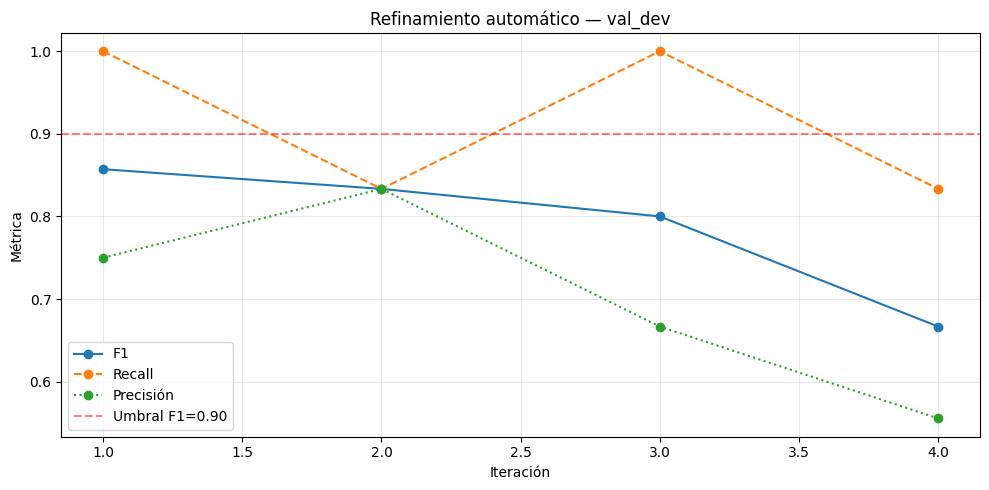

In [13]:
# ── Ejecutar refinamiento automático ─────────────────────────────────────────
initial_prompt_path = PROMPTS_DIR / 'prompt_v1.txt'

best_template, refinement_metrics = await auto_refine_loop(
    initial_template_path=initial_prompt_path,
    train_df=train_inner,
    val_dev_df=val_dev,
    max_iterations=15,
    target_f1=0.90,
    patience=3,
    seed=42,
)

# Mostrar evolución
display(
    refinement_metrics[['iteration', 'f1', 'recall', 'precision', 'accuracy', 'fn', 'fp', 'elapsed_s']]
    .round(4)
)

fig, ax = plt.subplots(figsize=(10, 5))
for col, label, ls in [('f1', 'F1', '-'), ('recall', 'Recall', '--'), ('precision', 'Precisión', ':')]:
    ax.plot(refinement_metrics['iteration'], refinement_metrics[col], marker='o', label=label, linestyle=ls)
ax.axhline(0.90, color='red', linestyle='--', alpha=0.5, label='Umbral F1=0.90')
ax.set_xlabel('Iteración')
ax.set_ylabel('Métrica')
ax.set_title('Refinamiento automático — val_dev')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── Iteración N ──────────────────────────────────────────────────────────────
# Edita prompt_vN.txt con las mejoras identificadas en el análisis de errores,
# luego actualiza el nombre y el número de iteración.

prompt_path = PROMPTS_DIR / "prompt_v5.txt"   # <-- cambiar versión
with open(prompt_path, encoding='utf-8') as f:
    prompt_template = f.read()

metrics_N = await run_iteration(
    iteration_num=6,              # <-- incrementar
    prompt_template=prompt_template,
    train_df=train_inner,
    val_df=val_inner,
    seed=42
)

Clasificando 1001 preguntas con gpt-4o-mini (0 en caché, 1001 llamadas nuevas)...


Clasificando:  65%|██████▌   | 652/1001 [1:03:31<42:26,  7.30s/preg]  

In [ ]:
FINAL_EVAL.mkdir(parents=True, exist_ok=True)
test_df = pd.read_csv(DATA_SPLITS / 'test_20.csv')

prompt_final_path = PROMPTS_DIR / 'prompt_v1.txt'  # <-- mejor prompt
if not prompt_final_path.exists():
    raise FileNotFoundError(f'No existe el prompt final: {prompt_final_path}')

with open(prompt_final_path, encoding='utf-8') as f:
    prompt_final = f.read()

best_seed = 42
acus_ex, no_acus_ex = sample_few_shot_examples(train_inner, n=4, seed=best_seed)
prompts_test = [
    build_prompt(prompt_final, acus_ex, no_acus_ex, q)
    for q in test_df['pregunta'].tolist()
]

raw_test = await classify_batch(prompts_test)
test_df = test_df.copy().reset_index(drop=True)
test_df['respuesta_llm'] = raw_test
test_df['prediccion'] = [parse_response(r) for r in raw_test]

valid_test = test_df[test_df['prediccion'] != -1].copy()
invalid_count = len(test_df) - len(valid_test)
if invalid_count:
    print(f'Aviso: {invalid_count} respuestas no se pudieron parsear y se excluyeron de las métricas.')

y_true_t = valid_test['etiqueta'].values
y_pred_t = valid_test['prediccion'].values

print()
print('=' * 60)
print('EVALUACIÓN FINAL — TEST_20')
print('=' * 60)
print(classification_report(y_true_t, y_pred_t, target_names=['No acusatoria', 'Acusatoria']))

final_metrics = {
    'f1': f1_score(y_true_t, y_pred_t, zero_division=0),
    'recall': recall_score(y_true_t, y_pred_t, zero_division=0),
    'precision': precision_score(y_true_t, y_pred_t, zero_division=0),
    'accuracy': accuracy_score(y_true_t, y_pred_t),
}
test_df.to_csv(FINAL_EVAL / 'final_preds.csv', index=False)
pd.DataFrame([final_metrics]).to_csv(FINAL_EVAL / 'final_metrics.csv', index=False)
print(f'Resultados guardados en {FINAL_EVAL}')

cm = confusion_matrix(y_true_t, y_pred_t)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No acusatoria', 'Acusatoria'],
            yticklabels=['No acusatoria', 'Acusatoria'], ax=ax)
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción LLM')
ax.set_title('Matriz de confusión — Evaluación final')
plt.tight_layout()
plt.show()

In [ ]:
def analyze_errors(iteration_num: int, max_examples: int = 10):
    preds_file = ITER_LOGS / f"iter_{iteration_num:02d}_preds.csv"
    if not preds_file.exists():
        print(f"No encontrado: {preds_file}")
        return None, None

    df = pd.read_csv(preds_file)
    fn_df = df[(df['etiqueta'] == 1) & (df['prediccion'] == 0)].reset_index(drop=True)
    fp_df = df[(df['etiqueta'] == 0) & (df['prediccion'] == 1)].reset_index(drop=True)

    print(f"{'='*60}")
    print(f"Iteración {iteration_num} — Análisis de errores")
    print(f"  Falsos Negativos (acusatoria → NO detectada): {len(fn_df)}")
    print(f"  Falsos Positivos (no acusatoria → marcada):   {len(fp_df)}")
    print(f"{'='*60}")

    if not fn_df.empty:
        print(f"\n── FALSOS NEGATIVOS (primeros {min(max_examples, len(fn_df))}) ──")
        for _, row in fn_df.head(max_examples).iterrows():
            print(f"\n  LLM: [{row.get('respuesta_llm','?')}]")
            print(f"  {row['pregunta'][:300]}")

    if not fp_df.empty:
        print(f"\n── FALSOS POSITIVOS (primeros {min(max_examples, len(fp_df))}) ──")
        for _, row in fp_df.head(max_examples).iterrows():
            print(f"\n  LLM: [{row.get('respuesta_llm','?')}]")
            print(f"  {row['pregunta'][:300]}")

    return fn_df, fp_df


# Cambiar el número según la iteración a analizar
fn_df, fp_df = analyze_errors(1)

## 10. Evolución de métricas

In [ ]:
log_file = ITER_LOGS / "iterations_log.csv"

if log_file.exists():
    metrics_df = pd.read_csv(log_file).sort_values('iteration')
    display(metrics_df[['iteration', 'f1', 'recall', 'precision', 'accuracy',
                         'fn', 'fp', 'elapsed_s']].round(4).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(10, 5))
    for col, label, ls in [('f1', 'F1', '-'), ('recall', 'Recall', '--'), ('precision', 'Precisión', ':')]:
        ax.plot(metrics_df['iteration'], metrics_df[col], marker='o', label=label, linestyle=ls)
    ax.axhline(0.90, color='red', linestyle='--', alpha=0.5, label='Umbral F1=0.90')
    ax.set_xlabel('Iteración')
    ax.set_ylabel('Métrica')
    ax.set_title('Evolución de métricas por iteración')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Aún no hay iteraciones registradas.")

## 11. Evaluación final

> **Ejecutar una sola vez** después de congelar el prompt definitivo.

Actualiza `prompt_final_path` con el nombre de tu mejor prompt antes de correr.

In [ ]:
FINAL_EVAL.mkdir(parents=True, exist_ok=True)
test_df = pd.read_csv(DATA_SPLITS / "test_20.csv")

prompt_final_path = PROMPTS_DIR / "prompt_v1.txt"   # <-- mejor prompt
with open(prompt_final_path, encoding='utf-8') as f:
    prompt_final = f.read()

best_seed = 42
acus_ex, no_acus_ex = sample_few_shot_examples(train_inner, n=4, seed=best_seed)
prompts_test = [
    build_prompt(prompt_final, acus_ex, no_acus_ex, q)
    for q in test_df['pregunta'].tolist()
]

raw_test = await classify_batch(prompts_test)
test_df = test_df.copy().reset_index(drop=True)
test_df['respuesta_llm'] = raw_test
test_df['prediccion']    = [parse_response(r) for r in raw_test]

valid_test = test_df[test_df['prediccion'] != -1]
y_true_t   = valid_test['etiqueta'].values
y_pred_t   = valid_test['prediccion'].values

print("\n" + "="*60)
print("EVALUACIÓN FINAL — TEST_20")
print("="*60)
print(classification_report(y_true_t, y_pred_t, target_names=['No acusatoria', 'Acusatoria']))

final_metrics = {
    'f1':        f1_score(y_true_t, y_pred_t, zero_division=0),
    'recall':    recall_score(y_true_t, y_pred_t, zero_division=0),
    'precision': precision_score(y_true_t, y_pred_t, zero_division=0),
    'accuracy':  accuracy_score(y_true_t, y_pred_t),
}
test_df.to_csv(FINAL_EVAL / "final_preds.csv", index=False)
pd.DataFrame([final_metrics]).to_csv(FINAL_EVAL / "final_metrics.csv", index=False)
print(f"Resultados guardados en {FINAL_EVAL}")

cm = confusion_matrix(y_true_t, y_pred_t)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No acusatoria', 'Acusatoria'],
            yticklabels=['No acusatoria', 'Acusatoria'], ax=ax)
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción LLM')
ax.set_title('Matriz de confusión — Evaluación final')
plt.tight_layout()
plt.show()

## 12. Comparación con ensemble del proyecto

Completa los valores `None` con los reportados en el documento de tesis.

In [ ]:
comparison = pd.DataFrame([
    {'Modelo': 'LLM Judge (prompt final)',  'F1': final_metrics['f1'],        'Recall': final_metrics['recall'],    'Precision': final_metrics['precision'], 'Accuracy': final_metrics['accuracy']},
    {'Modelo': 'Ensemble (M1+M2+M3)',       'F1': None, 'Recall': None, 'Precision': None, 'Accuracy': None},
    {'Modelo': 'Logistic Regression (M1)',  'F1': None, 'Recall': None, 'Precision': None, 'Accuracy': None},
    {'Modelo': 'Naive Bayes (M2)',          'F1': None, 'Recall': None, 'Precision': None, 'Accuracy': None},
    {'Modelo': 'Random Forest (M3)',        'F1': None, 'Recall': None, 'Precision': None, 'Accuracy': None},
])
display(comparison.round(4))